In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import numpy as np
import pandas as pd

from rich import print
import os

import scvi

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import colorcet as cc

from icecream import ic

# Set SVG font type
plt.rcParams["svg.fonttype"] = "none"

In [3]:
adata = ad.read_h5ad("/home/nathanl/Data/breast_sc_atlas_global.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 621200 × 37389
    obs: 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 
'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 
'sex_ontology_term_id', 'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch', 'is_primary_data', 
'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 
'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 
'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 
'schema_reference', 'schema_version', 'title'
    obsm: 'X_rpca', 'X_umap'

In [4]:
adata.obs.cell_type.value_counts()

cell_type
malignant cell                                                              242613
fibroblast                                                                   45702
macrophage                                                                   44437
effector memory CD8-positive, alpha-beta T cell                              29592
effector memory CD4-positive, alpha-beta T cell                              23696
natural killer cell                                                          23508
memory B cell                                                                21190
CD4-positive, CD25-positive, CCR4-positive, alpha-beta regulatory T cell     19802
naive T cell                                                                 18117
IgG plasma cell                                                              17824
exhausted T cell                                                             17359
CD8-positive, alpha-beta regulatory T cell                                   

In [5]:
adata.obs.author_cell_type.value_counts()

author_cell_type
epi_0             51241
epi_1             40441
epi_2             38378
CD8_Tem           29592
epi_low_ent       29062
                  ...  
cDC1                844
Endo Lymph.         769
Prolif Stromal      581
CD4_Th              419
epi_22              254
Name: count, Length: 62, dtype: int64

In [6]:
adata.obs[["cell_type", "author_cell_type"]]

,cell_type,author_cell_type
index,,
wu_natgen__CID3586_TTCTCCTTCTGAAAGA,malignant cell,epi_13
wu_natgen__CID3586_CTTACCGTCCTTTCGG,malignant cell,epi_2
wu_natgen__CID3586_TGATTTCGTCCGAGTC,malignant cell,epi_2
wu_natgen__CID3586_ATTATCCCAGAGCCAA,malignant cell,epi_2
wu_natgen__CID3586_CGACCTTGTAATCGTC,malignant cell,epi_2
...,...,...
wang__TACTCGCTCCGTAGTA-1,fibroblast,CAFs (LAMP5)
wang__TCAGGATTCGCTTAGA-1,fibroblast,CAFs (LAMP5)
wang__TCGGGACTCGCTGATA-1,vein endothelial cell,Endo Ven.


In [7]:
lymphoid = [
    "effector memory CD8-positive, alpha-beta T cell",
    "effector memory CD4-positive, alpha-beta T cell",
    "natural killer cell",
    "memory B cell",
    "CD4-positive, CD25-positive, CCR4-positive, alpha-beta regulatory T cell",
    "naive T cell",
    "IgG plasma cell",
    "exhausted T cell",
    "CD8-positive, alpha-beta regulatory T cell",
    "T follicular helper cell",
    "cycling T cell",
    "CD4-positive helper T cell",
]
myeloid = [
    "macrophage",
    "conventional dendritic cell",
    "cycling macrophage",
    "mast cell",
    "plasmacytoid dendritic cell",
    "myeloid dendritic cell",
]
fibroblasts = ["fibroblast", "myofibroblast cell"]
endothelial = [
    "endothelial cell",
    "vein endothelial cell",
    "endothelial cell of vascular tree",
    "endothelial cell of artery",
    "capillary endothelial cell",
]

cell_types_to_keep = ["malignant cell"] + fibroblasts + endothelial + myeloid + lymphoid
adata_endo_tumor = adata[adata.obs.cell_type.isin(cell_types_to_keep), :].copy()

def assign_broad(ct):
    if ct == "malignant cell":
        return "Malignant"
    if ct in fibroblasts:
        return "Fibroblast"
    if ct in endothelial:
        return "Endothelial"
    if ct in myeloid:
        return "Myeloid"
    if ct in lymphoid:
        return "Lymphoid"

adata_endo_tumor.obs["broad_cell_type"] = adata_endo_tumor.obs["cell_type"].map(assign_broad).astype("category")

In [8]:
adata_endo_tumor.var['feature_name']

ENSG00000286448    ENSG00000286448
ENSG00000225880          LINC00115
ENSG00000230368             FAM41C
ENSG00000187634             SAMD11
ENSG00000188976              NOC2L
                        ...       
ENSG00000286201    ENSG00000286201
ENSG00000288049    ENSG00000288049
ENSG00000286247    ENSG00000286247
ENSG00000288057    ENSG00000288057
ENSG00000286187    ENSG00000286187
Name: feature_name, Length: 37389, dtype: category
Categories (37361, object): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', ..., 'ZZEF1', 'ZZZ3', 'hsa-mir-1253', 'hsa-mir-423']

In [9]:
adata_endo_tumor.var_names = adata_endo_tumor.var['feature_name'].astype(str).tolist()
adata_endo_tumor.var_names_make_unique()

In [10]:
'FOXA1' in adata_endo_tumor.var_names

True

In [11]:
'KRT7' in adata_endo_tumor.var_names

True

In [15]:
figure_dir = '/home/nathanl/scviva_paper/breast/breast_proseg/figures_journal/'

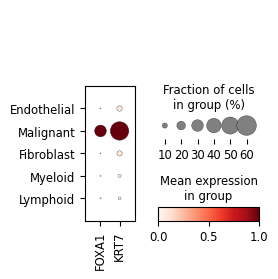

In [17]:
sc.pl.dotplot(
    adata_endo_tumor,
    var_names=["FOXA1", "KRT7"],
    groupby="broad_cell_type",
    categories_order=["Endothelial", "Malignant", "Fibroblast", "Myeloid", "Lymphoid"],
    standard_scale="var",
    use_raw=False,
    swap_axes=False,
    show=False,
)

# plt.tight_layout()
plt.savefig(f"{figure_dir}dotplot_scrna.svg", bbox_inches="tight", dpi=400)
plt.savefig(f"{figure_dir}dotplot_scrna.png", bbox_inches="tight", dpi=400)
plt.show()